In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from sympy.physics.vector import dynamicsymbols
from sympy.physics.mechanics import init_vprinting
import scipy.integrate as spi
from scipy.integrate import solve_ivp 

# Text display
from IPython.display import display, HTML, Math

# Initialize pretty printing with MathJax
init_vprinting(use_latex="mathjax")

# Define Dynamics

In [2]:
def display_alg_eq(lhs_exprs, rhs_exprs, eval=False, alist=True):
  if alist:
    return sp.Eq(sp.Matrix([[lhs] for lhs in lhs_exprs]), sp.Matrix([[rhs] for rhs in rhs_exprs]), evaluate=eval)
  else:
    return sp.Eq(lhs_exprs, rhs_exprs)
def display_diff_eq(states, dynamics, eval=False):
  return sp.Eq(sp.diff(sp.Matrix([[state] for state in states])), sp.Matrix([[dyn] for dyn in dynamics]), evaluate=eval)

state_dynamics = {} # key = variable, value = time derivative
algebraic_expressions = {} # key = variable, value = expresssion. For substitution in state_dynamics

In [3]:
""" Parameter and Variable Definitions """
# lower-case = variable, Upper case = expression

# Input (reference signal from outer loop)
v_c_d_ref, v_c_q_ref = sp.var("V_{c\mathrm{d}}^*, V_{c\mathrm{q}}^*") # reference capacitor voltage

# States
i_i_d, i_i_q = dynamicsymbols("I_{i\mathrm{d}}, I_{i\mathrm{q}}") # inverter/filter inductor current
v_c_d, v_c_q = dynamicsymbols("V_{c\mathrm{d}}, V_{c\mathrm{q}}") # capacitor voltage
i_g_d, i_g_q = dynamicsymbols("I_{g\mathrm{d}}, I_{g\mathrm{q}}") # grid side inductor current

phi_d, phi_q = dynamicsymbols("\Phi_\mathrm{d}, \Phi_\mathrm{q}") # voltage controller
gamma_d, gamma_q = dynamicsymbols("\Gamma_\mathrm{d}, \Gamma_\mathrm{q}") # current controller

# Algebraic Variables
v_i_d, v_i_q = dynamicsymbols("V_{i\mathrm{d}}, V_{i\mathrm{q}}") # inverter voltage (assumed equal to current controller reference)
i_i_d_ref, i_i_q_ref = dynamicsymbols("I_{i\mathrm{d}}^*, I_{i\mathrm{q}}^*") # reference inverter/filter inductor current from voltage controller
i_c_d, i_c_q = dynamicsymbols("i_{c\mathrm{d}}, i_{c\mathrm{q}}") # capacitor current
v_lg_d, v_lg_q = dynamicsymbols("v_{Lg\mathrm{d}}, v_{Lg\mathrm{q}}") # grid-side inductor voltage
v_li_d, v_li_q = dynamicsymbols("v_{Li\mathrm{d}}, v_{Li\mathrm{q}}") # inverter-side inductor voltage

# Parameters
omega, e_d, e_q = sp.var("\omega, E_\mathrm{d}, E_\mathrm{q}") # frequency and stiff grid voltage
r_i, l_i, c = sp.var("R_i, L_i, C") # inverter RLC filter parameters
r_g, l_g = sp.var("R_g, L_g") # grid RL branch parameters
k_pv, k_iv = sp.var("k_{pv},k_{iv}") # voltage controller PI gains
k_pi, k_ii = sp.var("k_{pi},k_{ii}") # current controller PI gains
J = sp.Matrix([[0,1],[-1,0]]) # clockwise 90 degree rotation matrix

# Collect dq components into vectors
v_c_dq_ref = sp.Matrix([v_c_d_ref, v_c_q_ref])

i_i_dq = sp.Matrix([i_i_d, i_i_q])
v_c_dq = sp.Matrix([v_c_d, v_c_q ])
i_g_dq = sp.Matrix([i_g_d, i_g_q])
phi_dq = sp.Matrix([phi_d, phi_q])
gamma_dq = sp.Matrix([gamma_d, gamma_q])

v_i_dq = sp.Matrix([v_i_d, v_i_q])
i_i_dq_ref = sp.Matrix([i_i_d_ref, i_i_q_ref])
i_c_dq = sp.Matrix([i_c_d, i_c_q])
v_lg_dq = sp.Matrix([v_lg_d, v_lg_q])
v_li_dq = sp.Matrix([v_li_d, v_li_q])

e_dq = sp.Matrix([e_d,e_q])

In [4]:
""" Line and Filter Dynamics """

# Update algebraic expressions
V_li_dq = v_i_dq - v_c_dq - r_i * i_i_dq
V_lg_dq = v_c_dq - e_dq - r_g * i_g_dq
I_c_dq = i_i_dq - i_g_dq

LCL_alg_lhs = [*v_li_dq, *v_lg_dq, *i_c_dq]
LCL_alg_rhs = [*V_li_dq, *V_lg_dq, *I_c_dq]

algebraic_expressions.update(zip(LCL_alg_lhs, LCL_alg_rhs))

# Update differential equations
I_i_dq_dot = (1/l_i) * v_li_dq + omega * J @ i_i_dq
I_g_dq_dot = (1/l_g) * v_lg_dq + omega * J @ i_g_dq
V_c_dq_dot = (1/c) * i_c_dq + omega * J @ v_c_dq

LCL_diff_lhs = [*i_i_dq, *i_g_dq, *v_c_dq]
LCL_diff_rhs = [*I_i_dq_dot, *I_g_dq_dot, *V_c_dq_dot]

state_dynamics.update(zip(LCL_diff_lhs, LCL_diff_rhs))

display_diff_eq(LCL_diff_lhs, LCL_diff_rhs, eval=False), display_alg_eq(LCL_alg_lhs,LCL_alg_rhs,eval=False,alist=True)

⎛                    ⎡                         v_{Li\mathrm{d}} ⎤              ↪
⎜                    ⎢\omega⋅I_{i\mathrm{q}} + ──────────────── ⎥              ↪
⎜                    ⎢                                Lᵢ        ⎥              ↪
⎜                    ⎢                                          ⎥              ↪
⎜                    ⎢                          v_{Li\mathrm{q}}⎥              ↪
⎜                    ⎢-\omega⋅I_{i\mathrm{d}} + ────────────────⎥              ↪
⎜⎡I_{i\maṫhrm{d}}⎤   ⎢                                 Lᵢ       ⎥  ⎡v_{Li\math ↪
⎜⎢               ⎥   ⎢                                          ⎥  ⎢           ↪
⎜⎢I_{i\maṫhrm{q}}⎥   ⎢                         v_{Lg\mathrm{d}} ⎥  ⎢v_{Li\math ↪
⎜⎢               ⎥   ⎢\omega⋅I_{g\mathrm{q}} + ──────────────── ⎥  ⎢           ↪
⎜⎢I_{g\maṫhrm{d}}⎥   ⎢                               L_g        ⎥  ⎢v_{Lg\math ↪
⎜⎢               ⎥ = ⎢                                          ⎥, ⎢           ↪
⎜⎢I_{g\maṫhrm{q}}⎥   ⎢  

In [5]:
""" Voltage Controller Loop Dynamics """

# Update differential equations 
Phi_dq_dot = v_c_dq_ref - v_c_dq

# Update algebraic expressions: VCL outputs I_i_dq ref signal for current controller
I_i_dq_ref = i_g_dq - omega * c * J @ v_c_dq + k_pv * Phi_dq_dot + k_iv * phi_dq

VCL_diff_lhs = [*phi_dq]
VCL_diff_rhs = [*Phi_dq_dot]

VCL_alg_lhs = [*i_i_dq_ref]
VCL_alg_rhs = [*I_i_dq_ref]

state_dynamics.update(zip(VCL_diff_lhs, VCL_diff_rhs))
algebraic_expressions.update(zip(VCL_alg_lhs, VCL_alg_rhs))

display_diff_eq(VCL_diff_lhs, VCL_diff_rhs, eval=False), display_alg_eq(VCL_alg_lhs,VCL_alg_rhs,eval=False,alist=True)

⎛⎡\Phi_\mȧthrm{d}⎤   ⎡V_{c\mathrm{d}}__* - V_{c\mathrm{d}}⎤  ⎡I_{i\mathrm{d}}_ ↪
⎜⎢               ⎥ = ⎢                                    ⎥, ⎢                 ↪
⎝⎣\Phi_\mȧthrm{q}⎦   ⎣V_{c\mathrm{q}}__* - V_{c\mathrm{q}}⎦  ⎣I_{i\mathrm{q}}_ ↪

↪ _*⎤   ⎡-C⋅\omega⋅V_{c\mathrm{q}} + k_{iv}⋅\Phi_\mathrm{d} + k_{pv}⋅(V_{c\mat ↪
↪   ⎥ = ⎢                                                                      ↪
↪ _*⎦   ⎣C⋅\omega⋅V_{c\mathrm{d}} + k_{iv}⋅\Phi_\mathrm{q} + k_{pv}⋅(V_{c\math ↪

↪ hrm{d}}__* - V_{c\mathrm{d}}) + I_{g\mathrm{d}}⎤⎞
↪                                                ⎥⎟
↪ rm{q}}__* - V_{c\mathrm{q}}) + I_{g\mathrm{q}} ⎦⎠

In [6]:
""" Current Controller Loop Dynamics """

# Update differential equations 
Gamma_dq_dot = i_i_dq_ref - i_i_dq

# Update algebraic expressions: CCL outputs V_i_dq ref signal that PWM automatically realizes -> V_i_dq
V_i_dq = v_c_dq - omega * l_i * J @ i_i_dq + k_pi * Gamma_dq_dot + k_ii * gamma_dq

CCL_diff_lhs = [*gamma_dq]
CCL_diff_rhs = [*Gamma_dq_dot]

CCL_alg_lhs = [*v_i_dq]
CCL_alg_rhs = [*V_i_dq]

state_dynamics.update(zip(CCL_diff_lhs, CCL_diff_rhs))
algebraic_expressions.update(zip(CCL_alg_lhs, CCL_alg_rhs))

display_diff_eq(CCL_diff_lhs, CCL_diff_rhs, eval=False), display_alg_eq(CCL_alg_lhs,CCL_alg_rhs,eval=False,alist=True)

⎛⎡\Gamma_\ṁathrm{d}⎤   ⎡-I_{i\mathrm{d}} + I_{i\mathrm{d}}__*⎤  ⎡V_{i\mathrm{d ↪
⎜⎢                 ⎥ = ⎢                                     ⎥, ⎢              ↪
⎝⎣\Gamma_\ṁathrm{q}⎦   ⎣-I_{i\mathrm{q}} + I_{i\mathrm{q}}__*⎦  ⎣V_{i\mathrm{q ↪

↪ }}⎤   ⎡-Lᵢ⋅\omega⋅I_{i\mathrm{q}} + k_{ii}⋅\Gamma_\mathrm{d} + k_{pi}⋅(-I_{i ↪
↪   ⎥ = ⎢                                                                      ↪
↪ }}⎦   ⎣Lᵢ⋅\omega⋅I_{i\mathrm{d}} + k_{ii}⋅\Gamma_\mathrm{q} + k_{pi}⋅(-I_{i\ ↪

↪ \mathrm{d}} + I_{i\mathrm{d}}__*) + V_{c\mathrm{d}}⎤⎞
↪                                                    ⎥⎟
↪ mathrm{q}} + I_{i\mathrm{q}}__*) + V_{c\mathrm{q}} ⎦⎠

In [7]:
# Put it all together
x = sp.Matrix([[i_i_d],[i_i_q],[i_g_d],[i_g_q],[v_c_d],[v_c_q],[phi_d],[phi_q],[gamma_d],[gamma_q]])
x_dot_simplified = sp.Matrix([[state_dynamics[state]] for state in x])
sp.Eq(sp.Symbol('x'), x, evaluate=False), display_diff_eq(x, x_dot_simplified)

⎛                                               ⎡                         v_{L ↪
⎜                                               ⎢\omega⋅I_{i\mathrm{q}} + ──── ↪
⎜                                               ⎢                              ↪
⎜                                               ⎢                              ↪
⎜                                               ⎢                          v_{ ↪
⎜                                               ⎢-\omega⋅I_{i\mathrm{d}} + ─── ↪
⎜    ⎡ I_{i\mathrm{d}} ⎤  ⎡ I_{i\maṫhrm{d}} ⎤   ⎢                              ↪
⎜    ⎢                 ⎥  ⎢                 ⎥   ⎢                              ↪
⎜    ⎢ I_{i\mathrm{q}} ⎥  ⎢ I_{i\maṫhrm{q}} ⎥   ⎢                         v_{L ↪
⎜    ⎢                 ⎥  ⎢                 ⎥   ⎢\omega⋅I_{g\mathrm{q}} + ──── ↪
⎜    ⎢ I_{g\mathrm{d}} ⎥  ⎢ I_{g\maṫhrm{d}} ⎥   ⎢                              ↪
⎜    ⎢                 ⎥  ⎢                 ⎥   ⎢                              ↪
⎜    ⎢ I_{g\mathrm{q}} ⎥ 

In [8]:
# Display full dynamics with algebraic expressions substituted in
# Do the substitution three times for nested use of algebraic variables
x_dot = sp.Matrix([[state_dynamics[state]] for state in x]).subs(algebraic_expressions).subs(algebraic_expressions).subs(algebraic_expressions)
display_diff_eq(x, x_dot)

                      ⎡                         -Lᵢ⋅\omega⋅I_{i\mathrm{q}} - R ↪
                      ⎢\omega⋅I_{i\mathrm{q}} + ────────────────────────────── ↪
                      ⎢                                                        ↪
                      ⎢                                                        ↪
                      ⎢                          Lᵢ⋅\omega⋅I_{i\mathrm{d}} - R ↪
                      ⎢-\omega⋅I_{i\mathrm{d}} + ───────────────────────────── ↪
⎡ I_{i\maṫhrm{d}} ⎤   ⎢                                                        ↪
⎢                 ⎥   ⎢                                                        ↪
⎢ I_{i\maṫhrm{q}} ⎥   ⎢                                                        ↪
⎢                 ⎥   ⎢                                                        ↪
⎢ I_{g\maṫhrm{d}} ⎥   ⎢                                                        ↪
⎢                 ⎥   ⎢                                                        ↪
⎢ I_{g\maṫhrm{q}} ⎥   ⎢ 

In [9]:
x_dot

⎡                         -Lᵢ⋅\omega⋅I_{i\mathrm{q}} - Rᵢ⋅I_{i\mathrm{d}} + k_ ↪
⎢\omega⋅I_{i\mathrm{q}} + ──────────────────────────────────────────────────── ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                          Lᵢ⋅\omega⋅I_{i\mathrm{d}} - Rᵢ⋅I_{i\mathrm{q}} + k_ ↪
⎢-\omega⋅I_{i\mathrm{d}} + ─────────────────────────────────────────────────── ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                           

# Plug in parameters
These are the required inputs:

$f_{nom},E_\mathrm{d},E_\mathrm{q}$

$R_i,R_g,L_i,L_g,C$

$f_{cur},f_{vol}$

From outer loop: $\Delta t,V_{c\mathrm{dq}}^*$ (old), $V_{c\mathrm{dq}}^*$ (new), $x0$ (guess)

In [10]:
# Nominal parameters
f_nom = 60 # Hz
omega_val = 2 * np.pi * f_nom
e_d_val = 120
e_q_val = 0

nom_subs = {omega: omega_val, e_d: e_d_val, e_q: e_q_val}

# Filter and line parameters
r_i_val, r_g_val = 0.4, 0.9
l_i_val, l_g_val =  1.5e-3, 2e-3
c_val = 10e-7

lcl_subs = {r_i:r_i_val, r_g:r_g_val, l_i:l_i_val, l_g:l_g_val, c:c_val}

# Controller parameters
freq_cur = 10000 #3000 #10000
freq_vol = 2000 #800 #2000

omega_cur = 2*np.pi*freq_cur
omega_vol = 2*np.pi*freq_vol

k_pv_val = 2*omega_vol*c_val
k_iv_val = 2*k_pv_val*omega_vol**2 / omega_cur

k_pi_val = l_i_val * omega_cur
k_ii_val = r_i_val * omega_cur

inner_control_subs = {k_pv:k_pv_val, k_iv:k_iv_val, k_pi:k_pi_val, k_ii:k_ii_val}

sim_numeric_subs = {**nom_subs, **lcl_subs, **inner_control_subs}


# Find x0

In [70]:
# Outer control loop parameters
delta_t = 0.01 #s
v_c_d_ref_val_old = 120.5 #V
v_c_q_ref_val_old = 11 #V
v_c_d_ref_val_new = 119.175398223686 #V
v_c_q_ref_val_new = -0.843982236861550 #V

# Find x0 based on Vc_dq_old (assuming steady state)
# at steady-state, I_i = I_g = Zg_inv @ (Vc_dq - E_dq)
# at steady-state, phi and gamma states are 0
# at steady-state, V_c_dq = V_c_dq_old
# TODO: SHOULD MAYBE CHANGE X0_GUESS TO ACTUALLY COME FROM DATA/PREVIOUS TIMESTAMP?
Z_g = sp.Matrix([[r_g, -omega * l_g],[omega*l_g, r_g]])
i_i_dq_val0 = Z_g.inv() @ (v_c_dq_ref - e_dq)
i_i_dq_val0 = i_i_dq_val0.subs(sim_numeric_subs).subs({v_c_d_ref:v_c_d_ref_val_old,v_c_q_ref:v_c_q_ref_val_old}).evalf()
x0_guess = [*i_i_dq_val0,*i_i_dq_val0,v_c_d_ref_val_old,v_c_q_ref_val_old,0,0,0,0]

x_dot_num = x_dot.subs(sim_numeric_subs).evalf()
f_t0 = x_dot_num.subs({v_c_d_ref:v_c_d_ref_val_old, v_c_q_ref:v_c_q_ref_val_old}).evalf()
x0 = sp.nsolve(f_t0,x,x0_guess)
x0 = np.array(x0).astype(np.float64).flatten()

# Solve ivp

In [74]:
t = sp.Symbol('t')
f_inputs = [t,x,v_c_d_ref, v_c_q_ref]
lambdify_x_dot = sp.lambdify(f_inputs, x_dot_num)

def f_x_dot(t, x, v_c_d_ref, v_c_q_ref):
  return np.array(lambdify_x_dot(t, x, v_c_d_ref, v_c_q_ref),dtype=float).flatten()

sol = solve_ivp(f_x_dot,[0,delta_t*5],x0, args=(v_c_d_ref_val_new, v_c_q_ref_val_new))

# RETURN: i_i (direct from sol) and v_i (by solving V_i_dq algebraic expression for all ts)

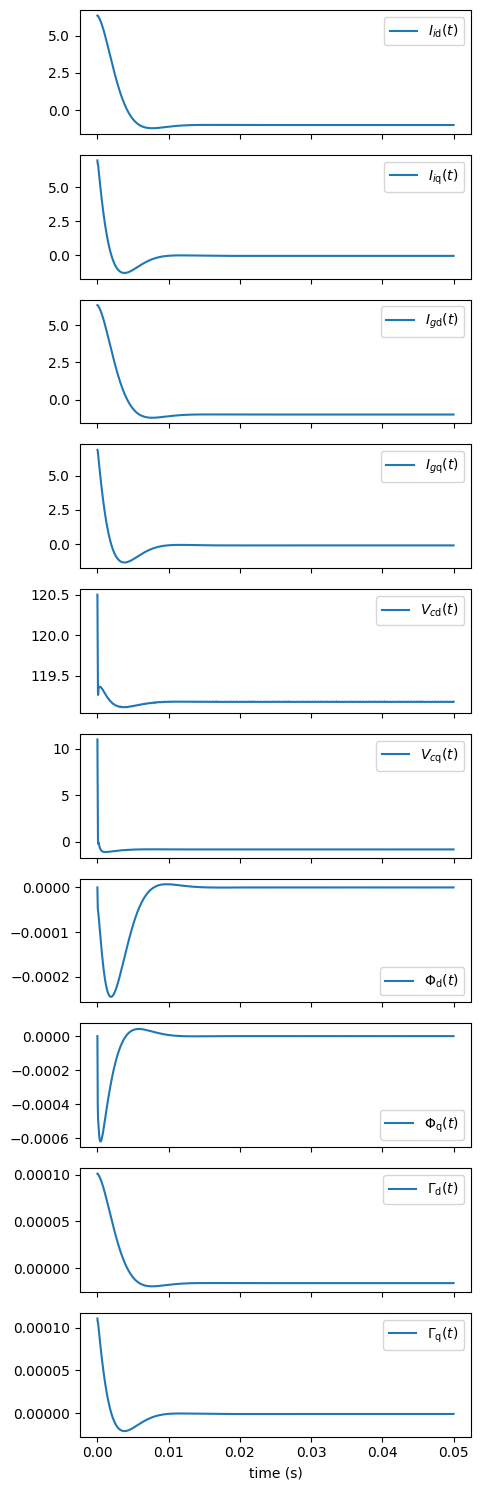

In [75]:
ts = sol.t
fig, axs = plt.subplots(len(x), 1, sharex=True,figsize=(5,15))
axs = axs.flatten()
for i, state in enumerate(x):
    axs[i].plot(ts, sol.y.T[:,i])
    x_sym = '$'+sp.latex(state)+'$'
    axs[i].legend([x_sym]);
plt.xlabel("time (s)");
plt.tight_layout()


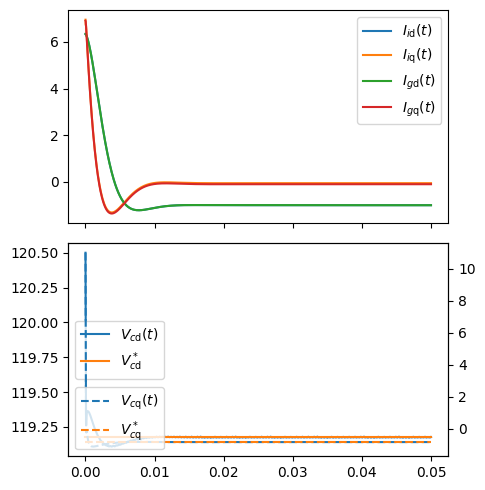

In [77]:
fig, (ax1,ax2) = plt.subplots(2, 1, sharex=True,figsize=(5,5))

for i, state in enumerate(x[0:4]):
    x_sym = '$'+sp.latex(state)+'$'
    ax1.plot(ts, sol.y.T[:,i], label=x_sym)
ax1.legend()
v_d_label = '$'+sp.latex(x[4])+'$'
v_q_label = '$'+sp.latex(x[5])+'$'
ax2.plot(ts, sol.y.T[:,4], label=v_d_label)
ax2.plot(ts, v_c_d_ref_val_new * np.ones(len(ts)),label=f"${v_c_d_ref}$")
ax3 = ax2.twinx()
ax3.plot(ts, sol.y.T[:,5], '--', label=v_q_label)
ax3.plot(ts, v_c_q_ref_val_new * np.ones(len(ts)),'--', label=f"${v_c_q_ref}$")
ax2.legend(loc="center left")
ax3.legend(loc="lower left")

plt.xlabel("time (s)");
plt.tight_layout()


In [78]:
V_i_dq_calc = sp.lambdify(x, V_i_dq.subs(algebraic_expressions).subs(sim_numeric_subs).subs({v_c_d_ref:v_c_d_ref_val_new, v_c_q_ref:v_c_q_ref_val_new}))

V_i_dq_sim_values = [V_i_dq_calc(*x_) for x_ in sol.y.T]

I_i_final = sol.y.T[-1,0:2]
I_g_final = sol.y.T[-1,2:4]
V_c_final = sol.y.T[-1,4:6]
V_i_final = V_i_dq_sim_values[-1]



In [79]:
Z_g.subs(sim_numeric_subs) @ np.array([-1,-0.1]) + np.array(e_dq.subs(sim_numeric_subs).evalf()).T

array([[119.175398223686, -0.843982236861550]], dtype=object)

In [67]:
Z_g.subs(sim_numeric_subs) @ I_i_final + np.array(e_dq.subs(sim_numeric_subs).evalf()).T

array([[120.876147636995, -0.0460249142706581]], dtype=object)

In [80]:
V_c_final

array([119.17703753,  -0.8448674 ])

In [81]:
V_i_final

array([[118.81170118],
       [ -1.42825172]])

In [82]:
I_g_final

array([-1.00000555, -0.0999788 ])

In [83]:
I_i_final

array([-0.99976319, -0.05507558])

# Test with inner_loop.py
(run this only, none of above cells)

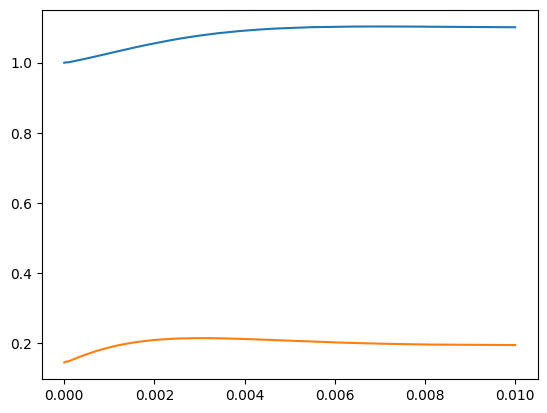

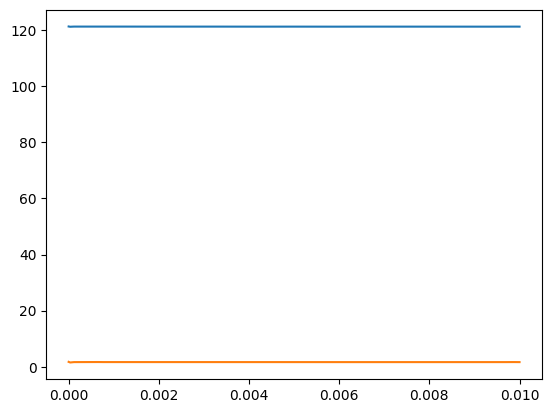

In [11]:
import helper_functions.inner_loop as il
import numpy as np
import matplotlib.pyplot as plt

i_i_dq_val_0 = np.array([1,0.1])
i_i_dq_ref_val_new = np.array([1.1,0.15])
e_dq_val = np.array([120,0])

r_i_val, r_g_val = 0.4, 0.9
l_i_val, l_g_val =  1.5e-3, 2e-3
c_val = 10e-7

ts, i_i_of_t, v_i_of_t = il.run_inner_loop(i_i_dq_val_0, i_i_dq_ref_val_new, e_dq_val, 
                   r_i_val, r_g_val, l_i_val, l_g_val, c_val)

plt.plot(ts,i_i_of_t[:,0])
plt.plot(ts,i_i_of_t[:,1])
plt.show()
plt.plot(ts,v_i_of_t[:,0])
plt.plot(ts,v_i_of_t[:,1])
plt.show()